In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

from tqdm.notebook import tqdm
from itertools import product
from typing import Union

In [ ]:
df = pd.read_csv('airline-passengers.csv')
df

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


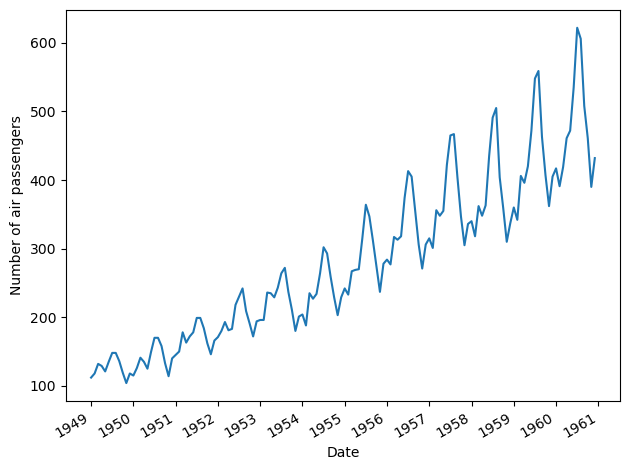

In [47]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')

plt.xticks(
    np.arange(0,145,12),
    np.arange(1949,1962,1)
)

fig.autofmt_xdate()
plt.tight_layout()

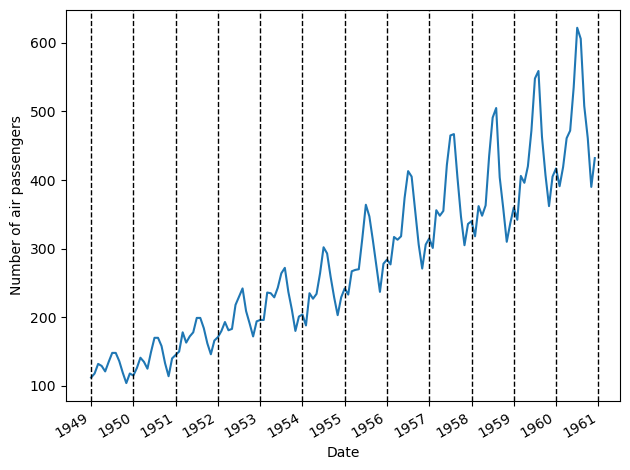

In [48]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
for i in np.arange(0, 145, 12):
    ax.axvline(x=i, linestyle='--', color='black', linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

## decomposing the serie

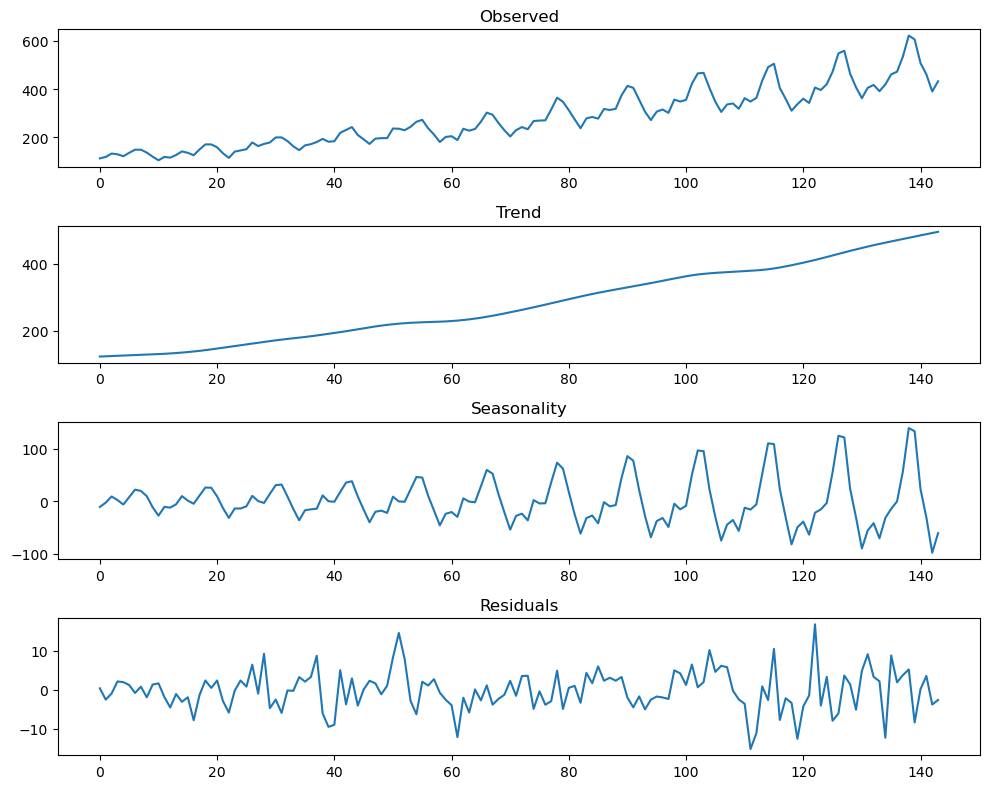

In [49]:
decomps =  STL(df['Passengers'], period=12).fit()

fig, ax = plt.subplots(4,1, figsize=(10,8))

decomps.observed.plot(ax=ax[0], title='Observed')
decomps.trend.plot(ax=ax[1], title='Trend')
decomps.seasonal.plot(ax=ax[2], title='Seasonality')
decomps.resid.plot(ax=ax[3], title='Residuals')

plt.tight_layout()

In [59]:
def adf_test(serie):
    test = adfuller(serie)

    print(f"Stat -> {test[0]}")
    print(f"Proba -> {test[1]}") #pvalue

    if serie[1] > 0.05:
        print('Not Stationnary') #H0:presence of unit root
    else:
        print("Stationnary") #H1: no unit root present

In [51]:
adf_test(df['Passengers'])

Stat -> 0.8153688792060456
Proba -> 0.991880243437641
Not Stationnary


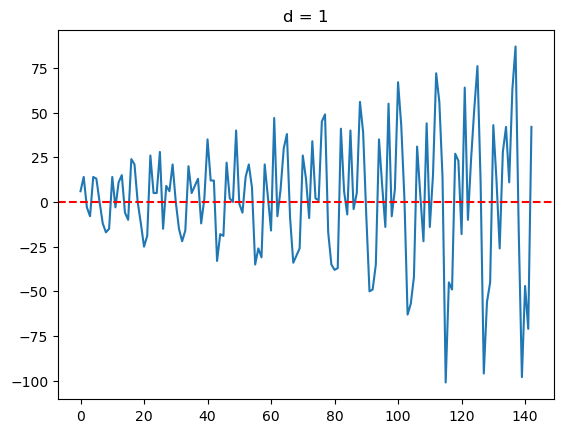

In [52]:
##first differentation:

df_diff = np.diff(df['Passengers'], n=1)

fig,ax = plt.subplots()
ax.plot(df_diff)
ax.axhline(y=0, color='red', linestyle='--')
plt.title('d = 1')
plt.show()

In [53]:
adf_test(df_diff)

Stat -> -2.8292668241700025
Proba -> 0.05421329028382508
Not Stationnary


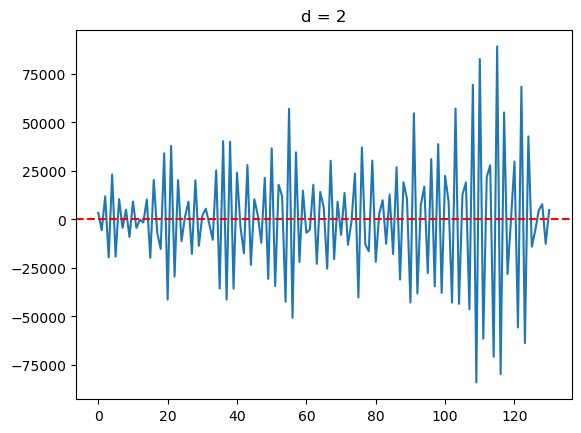

In [103]:
df_diff_2 = np.diff(df_diff, n=12)
fig,ax = plt.subplots()
ax.plot(df_diff_2)
ax.axhline(y=0, color='red', linestyle='--')
plt.title('d = 2')
plt.show()

In [104]:
adf_test(df_diff_2)

Stat -> -17.624862360208343
Proba -> 3.823046855816035e-30
Stationnary


d = 2 , 
D = 1

In [4]:
p = range(0,13,1)
q = range(0,13,1)
P = [0]
Q = [0]

d = 2
D = 0
s = 12

orders = list(product(p,q,P,Q))

In [57]:
orders

[(0, 0, 0, 0),
 (0, 1, 0, 0),
 (0, 2, 0, 0),
 (0, 3, 0, 0),
 (0, 4, 0, 0),
 (0, 5, 0, 0),
 (0, 6, 0, 0),
 (0, 7, 0, 0),
 (0, 8, 0, 0),
 (0, 9, 0, 0),
 (0, 10, 0, 0),
 (0, 11, 0, 0),
 (0, 12, 0, 0),
 (1, 0, 0, 0),
 (1, 1, 0, 0),
 (1, 2, 0, 0),
 (1, 3, 0, 0),
 (1, 4, 0, 0),
 (1, 5, 0, 0),
 (1, 6, 0, 0),
 (1, 7, 0, 0),
 (1, 8, 0, 0),
 (1, 9, 0, 0),
 (1, 10, 0, 0),
 (1, 11, 0, 0),
 (1, 12, 0, 0),
 (2, 0, 0, 0),
 (2, 1, 0, 0),
 (2, 2, 0, 0),
 (2, 3, 0, 0),
 (2, 4, 0, 0),
 (2, 5, 0, 0),
 (2, 6, 0, 0),
 (2, 7, 0, 0),
 (2, 8, 0, 0),
 (2, 9, 0, 0),
 (2, 10, 0, 0),
 (2, 11, 0, 0),
 (2, 12, 0, 0),
 (3, 0, 0, 0),
 (3, 1, 0, 0),
 (3, 2, 0, 0),
 (3, 3, 0, 0),
 (3, 4, 0, 0),
 (3, 5, 0, 0),
 (3, 6, 0, 0),
 (3, 7, 0, 0),
 (3, 8, 0, 0),
 (3, 9, 0, 0),
 (3, 10, 0, 0),
 (3, 11, 0, 0),
 (3, 12, 0, 0),
 (4, 0, 0, 0),
 (4, 1, 0, 0),
 (4, 2, 0, 0),
 (4, 3, 0, 0),
 (4, 4, 0, 0),
 (4, 5, 0, 0),
 (4, 6, 0, 0),
 (4, 7, 0, 0),
 (4, 8, 0, 0),
 (4, 9, 0, 0),
 (4, 10, 0, 0),
 (4, 11, 0, 0),
 (4, 12, 0, 0),
 (5, 0, 0,

In [58]:
len(orders)

169

In [6]:
def OptimizedSARIMA(endog:Union[pd.Series, list], order_list: list, d:int, D:int, s:int) -> pd.DataFrame:
    results = []

    for order in tqdm(order_list):
        try:
            model = SARIMAX(
                endog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
        aic = model.aic
        results.append([order, aic])

    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    return result_df

In [67]:
train = df['Passengers'][:-12]

ARIMA_res =  OptimizedSARIMA(train, orders, d, D, s)

  0%|          | 0/169 [00:00<?, ?it/s]

/usr/lib/python3/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lib/python3/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/lib/python3/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed 

In [68]:
ARIMA_res

,"(p,q,P,Q)",AIC
0,"(11, 3, 0, 0)",1016.845757
1,"(11, 4, 0, 0)",1019.035361
2,"(11, 5, 0, 0)",1020.378141
3,"(12, 0, 0, 0)",1020.577982
4,"(11, 1, 0, 0)",1021.019663
...,...,...
164,"(5, 0, 0, 0)",1281.732157
165,"(3, 0, 0, 0)",1300.282335
166,"(2, 0, 0, 0)",1302.913196
167,"(1, 0, 0, 0)",1308.152194


/usr/lib/python3/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/lib/python3/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


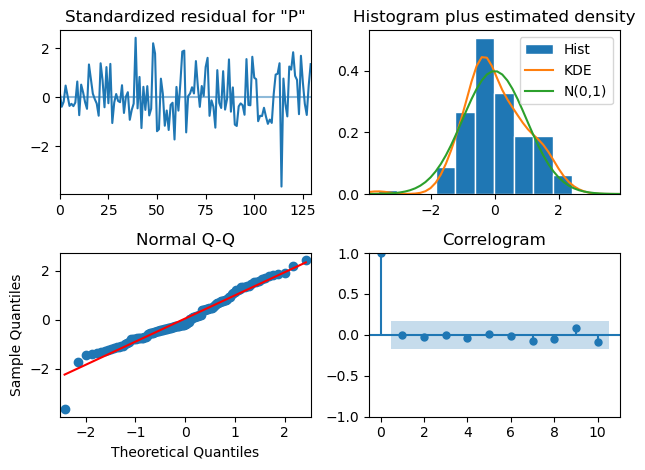

In [16]:
mld = SARIMAX(train, order=(11,2,3), simple_differencing=False)
rslt = mld.fit(disp=False)

rslt.plot_diagnostics()
plt.tight_layout()

In [17]:
from statsmodels.stats.diagnostic import acorr_ljungbox

pvalue = acorr_ljungbox(rslt.resid, np.arange(1,11,1))

In [75]:
print(pvalue)

      lb_stat  lb_pvalue
1    6.547487   0.010503
2    6.673558   0.035551
3    6.945765   0.073647
4    7.743118   0.101454
5    8.387911   0.136113
6    8.676206   0.192624
7    9.494326   0.219085
8    9.731984   0.284343
9    9.742016   0.371771
10  11.528118   0.317878


p values here all fails to reject H0 except for the first 2 this is
occuring due to the fact that we are trying to model seasonality with ARIMA that doesn't count it

In [22]:
test = df.iloc[-12:]
#baseline model: seasonal naive

test['naive_seasonal'] = df['Passengers'].iloc[120:132].values

/tmp/ipykernel_595834/2290453080.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['naive_seasonal'] = df['Passengers'].iloc[120:132].values


In [23]:
ARIMA_pred = rslt.get_prediction(132,143).predicted_mean

test['ARIMA_pred'] = ARIMA_pred

/tmp/ipykernel_595834/2874970876.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ARIMA_pred'] = ARIMA_pred


In [24]:
test

,Month,Passengers,naive_seasonal,ARIMA_pred
132,1960-01,417,360,422.293409
133,1960-02,391,342,410.648776
134,1960-03,419,406,461.831084
135,1960-04,461,396,457.743651
136,1960-05,472,420,481.620797
137,1960-06,535,472,530.976223
138,1960-07,622,548,606.128288
139,1960-08,606,559,615.427035
140,1960-09,508,463,525.642733
141,1960-10,461,407,467.173028


In [102]:
df_seasonal = np.diff(df_diff, n=12)
r = adfuller(df_seasonal)
'not statinnary' if r[1] > 0.05 else 'stationnary'

'stationnary'

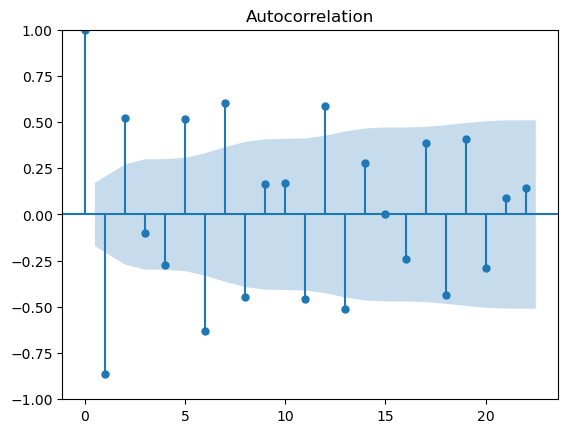

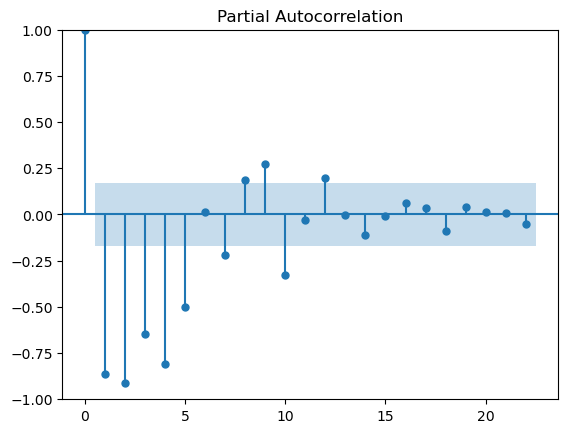

In [105]:
plot_acf(df_seasonal)
plot_pacf(df_seasonal)
plt.show()

In [7]:
p = range(0,4,1)
q = range(0,4,1)
P = range(0,4,1)
Q = range(0,4,1)

orders2 = list(product(p,q,P,Q))

In [107]:
orders2

[(0, 0, 0, 0),
 (0, 0, 0, 1),
 (0, 0, 0, 2),
 (0, 0, 0, 3),
 (0, 0, 1, 0),
 (0, 0, 1, 1),
 (0, 0, 1, 2),
 (0, 0, 1, 3),
 (0, 0, 2, 0),
 (0, 0, 2, 1),
 (0, 0, 2, 2),
 (0, 0, 2, 3),
 (0, 0, 3, 0),
 (0, 0, 3, 1),
 (0, 0, 3, 2),
 (0, 0, 3, 3),
 (0, 1, 0, 0),
 (0, 1, 0, 1),
 (0, 1, 0, 2),
 (0, 1, 0, 3),
 (0, 1, 1, 0),
 (0, 1, 1, 1),
 (0, 1, 1, 2),
 (0, 1, 1, 3),
 (0, 1, 2, 0),
 (0, 1, 2, 1),
 (0, 1, 2, 2),
 (0, 1, 2, 3),
 (0, 1, 3, 0),
 (0, 1, 3, 1),
 (0, 1, 3, 2),
 (0, 1, 3, 3),
 (0, 2, 0, 0),
 (0, 2, 0, 1),
 (0, 2, 0, 2),
 (0, 2, 0, 3),
 (0, 2, 1, 0),
 (0, 2, 1, 1),
 (0, 2, 1, 2),
 (0, 2, 1, 3),
 (0, 2, 2, 0),
 (0, 2, 2, 1),
 (0, 2, 2, 2),
 (0, 2, 2, 3),
 (0, 2, 3, 0),
 (0, 2, 3, 1),
 (0, 2, 3, 2),
 (0, 2, 3, 3),
 (0, 3, 0, 0),
 (0, 3, 0, 1),
 (0, 3, 0, 2),
 (0, 3, 0, 3),
 (0, 3, 1, 0),
 (0, 3, 1, 1),
 (0, 3, 1, 2),
 (0, 3, 1, 3),
 (0, 3, 2, 0),
 (0, 3, 2, 1),
 (0, 3, 2, 2),
 (0, 3, 2, 3),
 (0, 3, 3, 0),
 (0, 3, 3, 1),
 (0, 3, 3, 2),
 (0, 3, 3, 3),
 (1, 0, 0, 0),
 (1, 0, 0, 1),
 (1, 0, 0,

In [8]:
train = df['Passengers'][:-12]

d = 2
D = 1
s = 12

SARIMA_RES = OptimizedSARIMA(train, orders2, d,D,s)

  0%|          | 0/256 [00:00<?, ?it/s]

/usr/lib/python3/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/usr/lib/python3/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/usr/lib/python3/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lib/python3/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationar

In [31]:
SARIMA_RES

,"(p,q,P,Q)",AIC
0,"(2, 2, 1, 2)",892.180045
1,"(2, 2, 2, 1)",893.198733
2,"(3, 2, 1, 2)",893.404291
3,"(2, 2, 1, 3)",894.010756
4,"(3, 2, 2, 1)",894.270656
...,...,...
250,"(0, 0, 2, 1)",1006.262253
251,"(0, 0, 0, 3)",1006.296336
252,"(0, 0, 1, 2)",1006.296666
253,"(0, 0, 3, 1)",1008.125794


In [32]:
SARIMA_MODEL = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,2,12), simple_differencing=False)
result_M = SARIMA_MODEL.fit(disp=False)

SARIMA_PRED = result_M.get_prediction(132,143).predicted_mean

/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


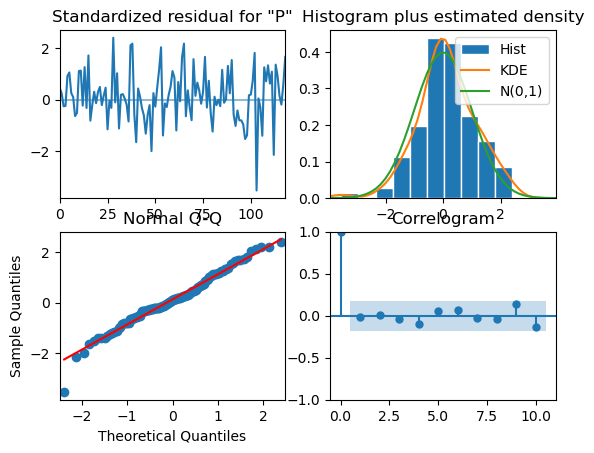

In [33]:
result_M.plot_diagnostics()
plt.show()

In [34]:
residuals = result_M.resid

pvalue = acorr_ljungbox(residuals)
print(pvalue)

     lb_stat  lb_pvalue
1   0.003855   0.950494
2   0.702022   0.703976
3   0.704375   0.872174
4   0.973506   0.913786
5   1.571467   0.904678
6   1.831603   0.934516
7   2.224246   0.946394
8   2.754738   0.948794
9   2.754749   0.973230
10  5.437943   0.860072


lb_pvalue > 0.05
Failing to reject H0 (H0: residuals are indepedant and normal)

In [25]:
test

,Month,Passengers,naive_seasonal,ARIMA_pred
132,1960-01,417,360,422.293409
133,1960-02,391,342,410.648776
134,1960-03,419,406,461.831084
135,1960-04,461,396,457.743651
136,1960-05,472,420,481.620797
137,1960-06,535,472,530.976223
138,1960-07,622,548,606.128288
139,1960-08,606,559,615.427035
140,1960-09,508,463,525.642733
141,1960-10,461,407,467.173028


In [26]:
test['SARIMA_pred'] = SARIMA_PRED

/tmp/ipykernel_595834/2837125423.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['SARIMA_pred'] = SARIMA_PRED


In [39]:
test

,Month,Passengers,naive_seasonal,ARIMA_pred,SARIMA_pred
132,1960-01,417,360,422.293409,418.425219
133,1960-02,391,342,410.648776,395.930578
134,1960-03,419,406,461.831084,456.773305
135,1960-04,461,396,457.743651,444.118777
136,1960-05,472,420,481.620797,465.902046
137,1960-06,535,472,530.976223,528.308810
138,1960-07,622,548,606.128288,601.649490
139,1960-08,606,559,615.427035,612.175362
140,1960-09,508,463,525.642733,507.575286
141,1960-10,461,407,467.173028,448.932593


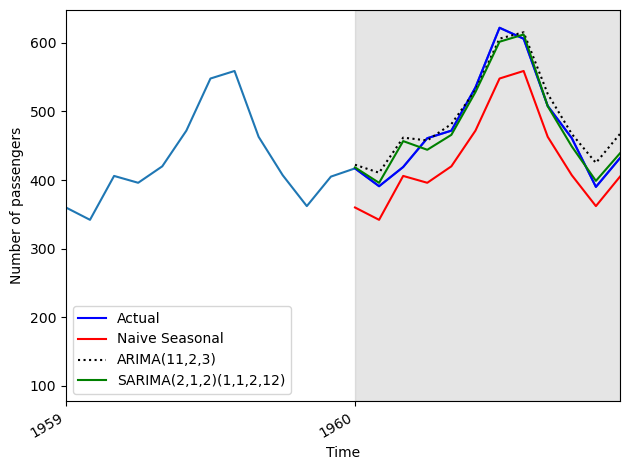

In [54]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
ax.plot(test['Passengers'], 'b-', label='Actual')
ax.plot(test['naive_seasonal'], 'r-', label='Naive Seasonal')
ax.plot(test['ARIMA_pred'], 'k:', label='ARIMA(11,2,3)')
ax.plot(test['SARIMA_pred'], 'g-', label='SARIMA(2,1,2)(1,1,2,12)')

ax.set_xlabel('Time')
ax.set_ylabel('Number of passengers')
ax.axvspan(132,143, color='grey', alpha=0.2)

plt.xticks(
    np.arange(0,145,12),
    np.arange(1949,1962,1)
)
ax.set_xlim(120, 143)
fig.autofmt_xdate()
plt.legend()
plt.tight_layout()

In [49]:
mape_ns = mean_absolute_percentage_error(test['Passengers'], test['naive_seasonal'])
mape_arima = mean_absolute_percentage_error(test['Passengers'], test['ARIMA_pred'])
mape_sarima = mean_absolute_percentage_error(test['Passengers'], test['SARIMA_pred'])

In [50]:
print(mape_ns, mape_arima, mape_sarima)

0.09987532920823484 0.03841375023779768 0.023085423501810146


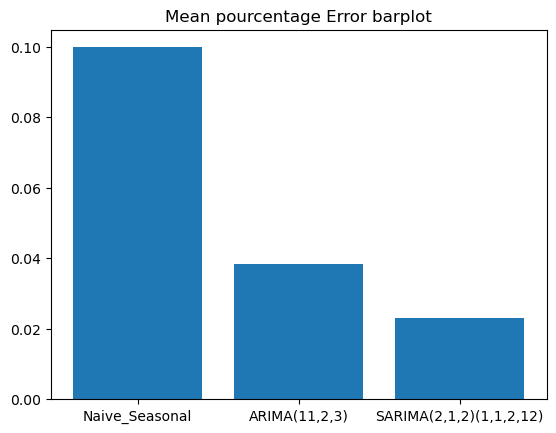

In [58]:
X = ['Naive_Seasonal', 'ARIMA(11,2,3)', 'SARIMA(2,1,2)(1,1,2,12)']
Y = [mape_ns, mape_arima, mape_sarima]

plt.bar(X, Y)
plt.title("Mean pourcentage Error barplot")
plt.show()

SARIMA MODEL have the lowest mape, 2.30%
meaning the model's predictions were off by 2.30% from the actual values

In [52]:
result_M.params

ar.L1        0.406330
ar.L2        0.407317
ma.L1       -0.751813
ma.L2       -0.224581
ar.S.L12     0.995295
ma.S.L12    -1.295253
ma.S.L24     0.339233
sigma2      83.067216
dtype: float64